# Types and parameters of box whiskers plots

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Randomly generated data

Data are composed of three equally distributed samples (`spread`, `flier_high`, `flier_low`). In addition, 25 times the 50 are inserted in the middle of the interval (`center`).

## Task

Modify the histogram to look at each subsample. To do this, keep the area represented by the x-axis constant. What happens if you also do this for the respective box plots (this time keep the division of the y-axis constant)?

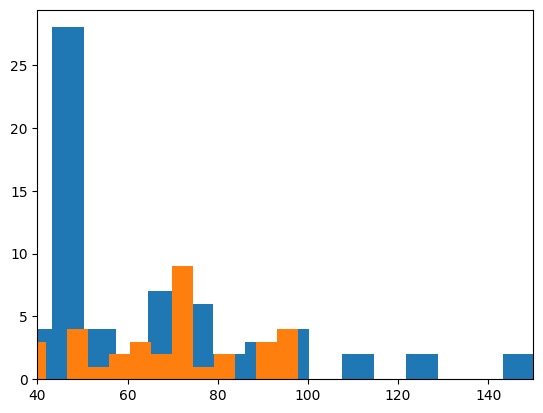

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Fixing random state for reproducibility
np.random.seed(19680801)

# fake up some data
spread = np.random.rand(50) * 100
center = np.ones(25) * 50
flier_high = np.random.rand(10) * 100 + 100
flier_low = np.random.rand(10) * -100
data = np.concatenate((spread, center, flier_high, flier_low))

plt.hist(data, bins=40)

plt.hist(spread, bins=20)
plt.xlim(40, 150)

plt.show()

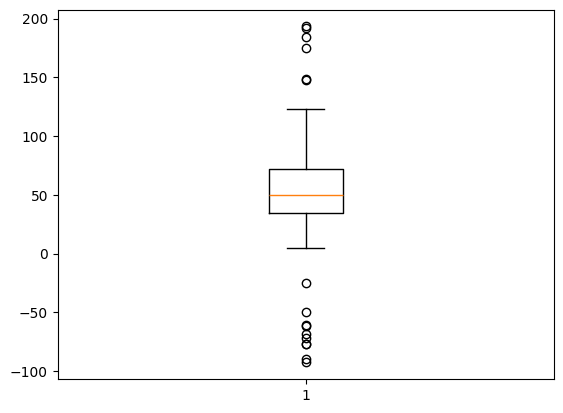

In [7]:
plt.boxplot(data, showfliers=True)
plt.show()

# Representation of real data

The dataset, originally from Keggle, contains various measurements from patients who had expressed breast cancer. The data is labeled as to whether the tumors were benign or malignant. For the boxplot, the size of the area occupied by the tumor is compared for benign and malignant tumors, respectively.

In [23]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/mGalarnyk/'
                 + 'Python_Tutorials/master/Kaggle/BreastCancerWisconsin/data/data.csv')

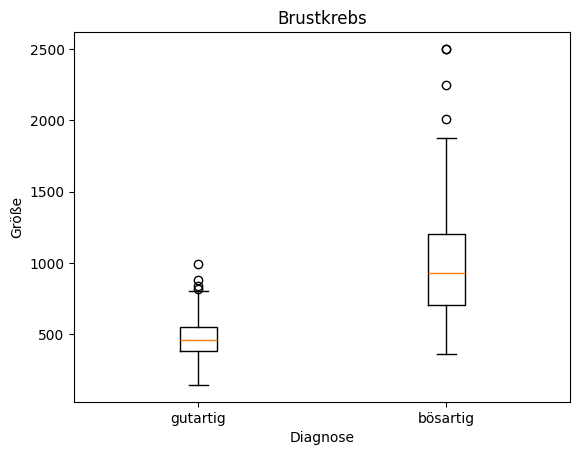

In [25]:
malignant = df[df['diagnosis']=='M']['area_mean']
benign = df[df['diagnosis']=='B']['area_mean']

plt.boxplot([benign, malignant], labels=['gutartig','bösartig'])
plt.ylabel("Größe")
plt.xlabel("Diagnose")
plt.title("Brustkrebs")
plt.show()


Text(0.5, 1.0, '')

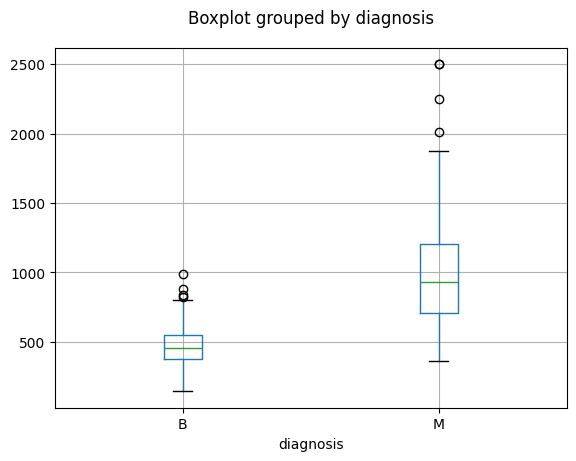

In [13]:
df.boxplot(column = 'area_mean', by = 'diagnosis');
plt.title('')

## Task

Using Box-Whiskers plots, investigate which characteristics might be appropriate for diagnosing breast cancer in a patient.

In [8]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


ডেটাসেটের সব কলামের নাম:
 Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

ক্যান্সার সনাক্তকরণের জন্য সবচেয়ে সেরা বৈশিষ্ট্যগুলো হলো: ['concave points_worst']


<Figure size 600x400 with 0 Axes>

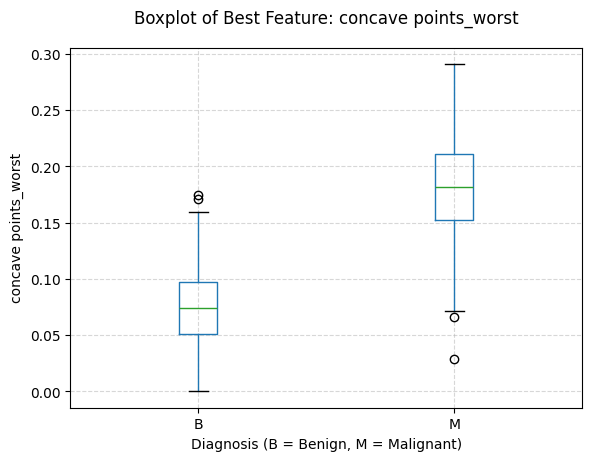

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ১. ডেটাসেট লোড করা
url = 'https://raw.githubusercontent.com/mGalarnyk/Python_Tutorials/master/Kaggle/BreastCancerWisconsin/data/data.csv'
df = pd.read_csv(url)

# ২. কম্পিউটারকে সব কলাম দেখানোর নির্দেশ দেওয়া
pd.set_option('display.max_columns', None)
print("ডেটাসেটের সব কলামের নাম:\n", df.columns)

# ৩. 'diagnosis' কলামকে গাণিতিক সংখ্যায় রূপান্তর (M = 1, B = 0) যাতে হিসাব সুবিধা হয়
df['target'] = df['diagnosis'].map({'M': 1, 'B': 0})

# ৪. শুধু সংখ্যাযুক্ত কলামগুলো আলাদা করা (id, diagnosis ও target বাদ দিয়ে)
numeric_df = df.drop(columns=['id', 'diagnosis'])

# ৫. প্রতিটি বৈশিষ্ট্যের সাথে ক্যান্সারের সম্পর্ক (Correlation) বের করা
# যার কোরিলেশন ১ এর যত কাছাকাছি, সেটি ক্যান্সার সনাক্তকরণের জন্য তত বেশি শক্তিশালী
correlations = numeric_df.corr()['target'].sort_values(ascending=False)

# 'target' নিজের সাথে কোরিলেশন বাদ দিয়ে শীর্ষ সেরা ৪টি বৈশিষ্ট্য বেছে নেওয়া
# সাধারণত perimeter_mean, area_mean, radius_mean এবং perimeter_worst সবচেয়ে সেরা আসে
best_features = correlations.index[1:2].tolist()

print("\nক্যান্সার সনাক্তকরণের জন্য সবচেয়ে সেরা বৈশিষ্ট্যগুলো হলো:", best_features)

# ৬. এবার স্বয়ংক্রিয়ভাবে শুধু সেই সেরা বৈশিষ্ট্যগুলোর বক্স প্লট তৈরি করা
for feature in best_features:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=feature, by='diagnosis')
    
    plt.title('')
    plt.suptitle(f'Boxplot of Best Feature: {feature}', fontsize=12)
    plt.xlabel('Diagnosis (B = Benign, M = Malignant)')
    plt.ylabel(feature)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=1e91bd54-be52-46c8-8e4a-baf88d675b91' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>